# Assignment 15: Loan Default Prediction

**Student Name:** Mohammad Tamim Hamkar

## Step 1: Introduction

Loan default can create financial risk for banks and other lending institutions. Machine learning can help identify borrowers who may be more likely to default by finding patterns in financial and personal data.

This project uses a loan dataset to build a prediction model, evaluate its performance, identify important factors related to default, and examine fairness and ethical considerations.


## Step 2: Load and Explore the Dataset

The bank loan dataset contains information about borrowers that can be used to study patterns related to loan default. The dataset is loaded and explored to understand its size, features, missing values, and basic statistics.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
data = pd.read_csv("/content/bank-loan.csv")

# Display basic information
print("Dataset shape:", data.shape)

print("\nFirst 5 rows:")
display(data.head())

print("\nDataset information:")
data.info()

print("\nSummary statistics:")
display(data.describe())

print("\nMissing values:")
print(data.isnull().sum())

Dataset shape: (850, 9)

First 5 rows:


,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       850 non-null    int64  
 1   ed        850 non-null    int64  
 2   employ    850 non-null    int64  
 3   address   850 non-null    int64  
 4   income    850 non-null    int64  
 5   debtinc   850 non-null    float64
 6   creddebt  850 non-null    float64
 7   othdebt   850 non-null    float64
 8   default   700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 59.9 KB

Summary statistics:


,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
count,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,700.000000
mean,35.029412,1.710588,8.565882,8.371765,46.675294,10.171647,1.576805,3.078789,0.261429
std,8.041432,0.927784,6.777884,6.895016,38.543054,6.719441,2.125840,3.398803,0.439727
min,20.000000,1.000000,0.000000,0.000000,13.000000,0.100000,0.011696,0.045584,0.000000
25%,29.000000,1.000000,3.000000,3.000000,24.000000,5.100000,0.382176,1.045942,0.000000
50%,34.000000,1.000000,7.000000,7.000000,35.000000,8.700000,0.885091,2.003243,0.000000
75%,41.000000,2.000000,13.000000,12.000000,55.750000,13.800000,1.898440,3.903001,1.000000
max,56.000000,5.000000,33.000000,34.000000,446.000000,41.300000,20.561310,35.197500,1.000000



Missing values:
age           0
ed            0
employ        0
address       0
income        0
debtinc       0
creddebt      0
othdebt       0
default     150
dtype: int64


## Step 3: Clean the Dataset

The dataset is checked for missing values before modeling. Since the missing values are in the target variable (`default`), those rows are removed rather than guessing whether a borrower defaulted or not.

In [3]:
# Remove rows where the target value is missing
data_clean = data.dropna(subset=["default"]).copy()

# Convert the target to integer values
data_clean["default"] = data_clean["default"].astype(int)

print("Original dataset:", data.shape)
print("Cleaned dataset:", data_clean.shape)

print("\nMissing values after cleaning:")
print(data_clean.isnull().sum())

print("\nDefault distribution:")
print(data_clean["default"].value_counts())

Original dataset: (850, 9)
Cleaned dataset: (700, 9)

Missing values after cleaning:
age         0
ed          0
employ      0
address     0
income      0
debtinc     0
creddebt    0
othdebt     0
default     0
dtype: int64

Default distribution:
default
0    517
1    183
Name: count, dtype: int64


## Step 4: Exploratory Data Analysis

Visualizing the data helps show how borrower characteristics are distributed and how some financial factors may be related to loan default. The charts below compare the target classes and explore important features such as age, income, and debt-to-income ratio.

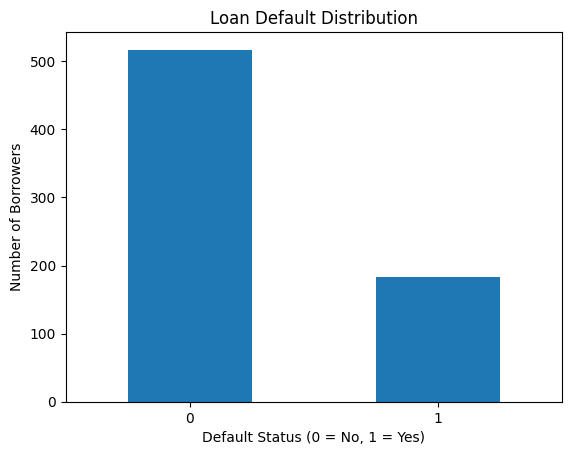

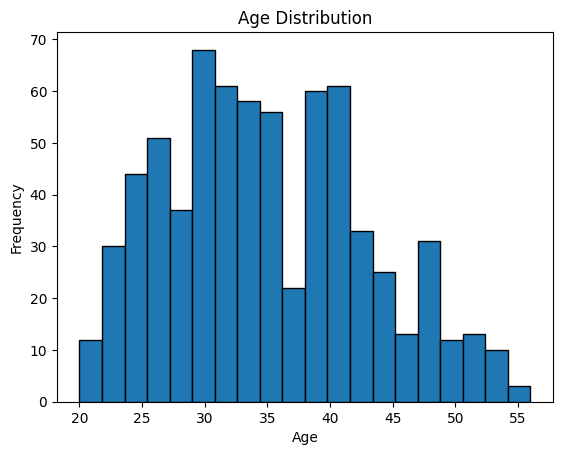

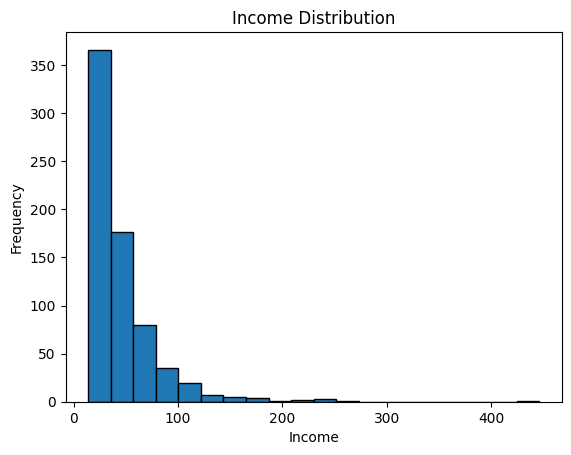

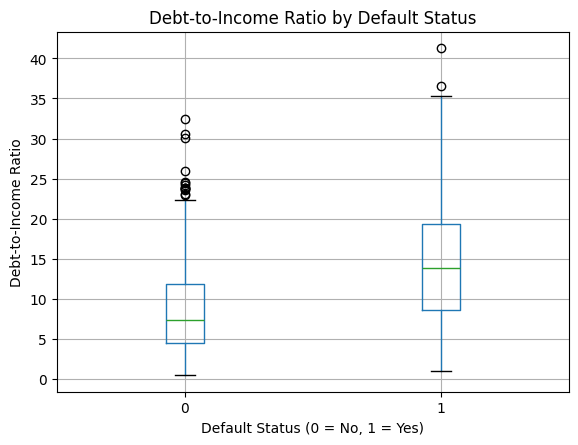

In [4]:
# Distribution of loan default
data_clean["default"].value_counts().sort_index().plot(kind="bar")

plt.title("Loan Default Distribution")
plt.xlabel("Default Status (0 = No, 1 = Yes)")
plt.ylabel("Number of Borrowers")
plt.xticks(rotation=0)
plt.show()

# Age distribution
plt.hist(data_clean["age"], bins=20, edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Income distribution
plt.hist(data_clean["income"], bins=20, edgecolor="black")
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

# Debt-to-income ratio by default status
data_clean.boxplot(column="debtinc", by="default")

plt.title("Debt-to-Income Ratio by Default Status")
plt.suptitle("")
plt.xlabel("Default Status (0 = No, 1 = Yes)")
plt.ylabel("Debt-to-Income Ratio")
plt.show()

## Step 5: Feature Engineering

A new feature called Total Debt is created by combining credit debt and other debt. This gives a clearer picture of a borrower's overall debt and may help the model identify patterns related to loan default.

In [5]:
# Create a new feature for total debt
data_clean["totaldebt"] = (
    data_clean["creddebt"] + data_clean["othdebt"]
)

print("New feature created successfully.")

# Display the new feature with related columns
display(
    data_clean[
        ["creddebt", "othdebt", "totaldebt", "default"]
    ].head()
)

New feature created successfully.


,creddebt,othdebt,totaldebt,default
0,11.359392,5.008608,16.368,1
1,1.362202,4.000798,5.363,0
2,0.856075,2.168925,3.025,0
3,2.658720,0.821280,3.480,0
4,1.787436,3.056564,4.844,1


## Step 6: Prepare and Scale the Features

The features are separated from the loan default target and divided into training and testing sets. Numerical features are scaled so that differences in their ranges do not affect the modeling process.

In [6]:
# Import preprocessing tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = data_clean.drop("default", axis=1)
y = data_clean["default"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled data back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print("Training set:", X_train_scaled.shape)
print("Testing set:", X_test_scaled.shape)

Training set: (560, 9)
Testing set: (140, 9)


## Step 7: Train the Random Forest Model

A Random Forest classifier is used to predict whether a borrower will default on a loan. This model combines multiple decision trees to make the final prediction.

In [7]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Create the model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## Step 8: Model Evaluation

The model is evaluated using accuracy, a confusion matrix, and a classification report. These results help show how well the model identifies borrowers who default and those who do not.

In [8]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

# Display confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 82.86 %

Confusion Matrix:
[[94  9]
 [15 22]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.89       103
           1       0.71      0.59      0.65        37

    accuracy                           0.83       140
   macro avg       0.79      0.75      0.77       140
weighted avg       0.82      0.83      0.82       140



## Step 9: Feature Importance

Feature importance helps identify which borrower characteristics have the strongest influence on the model's loan default predictions.

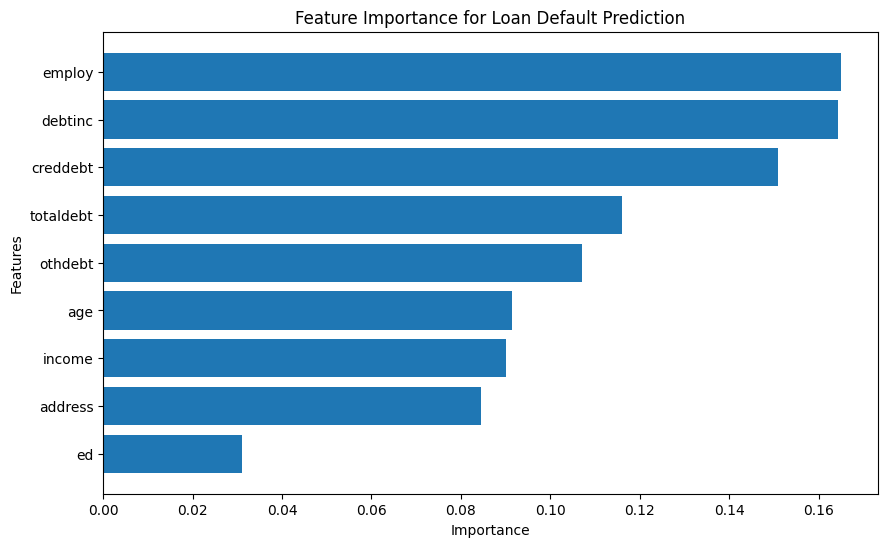

In [9]:
# Get feature importance from the Random Forest model
importances = model.feature_importances_
features = X_train.columns

# Sort features from most to least important
indices = np.argsort(importances)[::-1]

# Create feature importance graph
plt.figure(figsize=(10, 6))
plt.barh(features[indices], importances[indices])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance for Loan Default Prediction")
plt.gca().invert_yaxis()
plt.show()

## Step 10: SHAP Explainability

SHAP helps explain how each feature influences the model's loan default predictions. The summary plot shows which features have the greatest overall impact on the model.

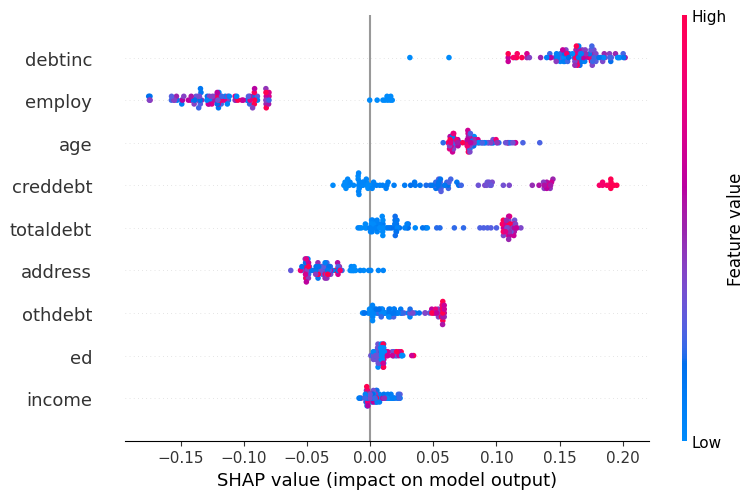

In [10]:
# Import SHAP
import shap

# Create SHAP explainer for the Random Forest model
explainer = shap.TreeExplainer(model)

# Use a sample of the testing data
X_shap = X_test.iloc[:100]

# Calculate SHAP values
shap_values = explainer(X_shap)

# Create SHAP summary plot for loan default predictions
shap.summary_plot(
    shap_values[:, :, 1],
    X_shap,
    feature_names=X_shap.columns
)

## Step 11: Fairness Analysis

The dataset does not include gender, so age groups are used to check whether the model performs differently across demographic groups.

Model Accuracy by Age Group:
Age Group
30 and Under    0.727273
31-40           0.873016
Over 40         0.878788
dtype: float64


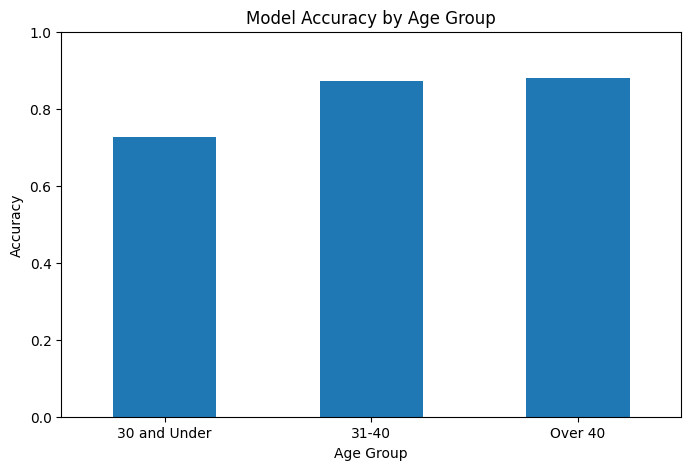

In [11]:
# Create age groups using the original age values
age_test = data_clean.loc[X_test.index, "age"]

age_groups = pd.cut(
    age_test,
    bins=[0, 30, 40, 100],
    labels=["30 and Under", "31-40", "Over 40"]
)

# Compare model accuracy across age groups
fairness_results = pd.DataFrame({
    "Age Group": age_groups,
    "Actual": y_test,
    "Predicted": y_pred
})

group_accuracy = fairness_results.groupby(
    "Age Group",
    observed=False
).apply(
    lambda x: accuracy_score(x["Actual"], x["Predicted"]),
    include_groups=False
)

print("Model Accuracy by Age Group:")
print(group_accuracy)

# Visualize the results
group_accuracy.plot(kind="bar", figsize=(8, 5))
plt.title("Model Accuracy by Age Group")
plt.ylabel("Accuracy")
plt.xlabel("Age Group")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

## Step 12: Fairness Analysis and Recommendations

The fairness analysis shows that the model does not perform equally across all age groups. It has lower accuracy for borrowers age 30 and under, while it performs better for borrowers over 30.

This difference is important because loan decisions can have a major impact on people's lives. A model should not unfairly disadvantage someone because of their age.

To improve fairness, the institution could use more balanced training data, regularly compare model performance across age groups, and review important loan decisions with human oversight. The model should support decision-making rather than make important lending decisions completely on its own.

## Step 13: Ethical Considerations

Using AI for loan default prediction can help financial institutions understand risk, but it must be used responsibly.

**Fairness:**  
The model showed different accuracy levels across age groups, especially for borrowers age 30 and under. The institution should regularly check the model for bias and make sure that certain groups are not treated unfairly.

**Privacy:**  
Loan information contains sensitive personal and financial data. This information should be protected, stored securely, and only used for its intended purpose.

**Transparency:**  
Borrowers should be able to understand why a loan decision was made. SHAP helps explain which factors influenced the model's predictions instead of treating the model as a black box.

**Improvements:**  
The model could be improved by using more balanced and representative data, checking fairness regularly, and having a human review important or uncertain decisions.

Overall, AI can support loan decisions, but it should not replace responsible human judgment. Fairness, privacy, and transparency should remain important throughout the process.

## Step 14: Conclusion and Recommendations

The Random Forest model achieved an accuracy of 82.86%, showing that it can identify patterns related to loan default reasonably well. The analysis showed that employment, debt-to-income ratio, credit debt, and total debt were important factors in the predictions.

The SHAP analysis also helped explain how different borrower characteristics affected the model's decisions. The fairness analysis showed that the model was less accurate for borrowers age 30 and under, which means fairness should continue to be monitored.

The financial institution could use this model as a tool to identify higher-risk loans and provide early support to borrowers. However, predictions should be reviewed carefully, especially when they may affect important lending decisions. Using better-balanced data, monitoring fairness, protecting customer information, and keeping human review in the process can make the system safer and more responsible.